In [1]:
import pandas as pd 

In [37]:
INPUT_PATH = '/Users/cloudmaple/Downloads/Microsoft_Interview/Tech_Coding/'
df = pd.read_csv(INPUT_PATH + 'interviewCase_IDE_expanded_strong_cohort.csv')

In [38]:
df.head()

,date,userid,startdate,plan,Status,DayOfWeek,Weekend,DaysSinceStart,AI_AutoComplete_Success,AI_AutoComplete_Error,AI_Chat_Success,AI_Chat_Error,AI_Agent_Success,AI_Agent_Error
0,03/03/2025,10000000,2025-03-03,Free,Active,Monday,0,0.0,28.0,2.0,NaN,1.0,3.0,0.0
1,03/04/2025,10000000,03/03/2025,Free,Active,Tuesday,FALSE,1.0,27.0,1.5,4.0,1.0,2.0,1.0
2,05-Mar-2025,10000000,03/03/2025,Free,Active,Wednesday,False,2.0,27.0,2.0,3.0,1.0,2.0,NaN
3,03-06-2025,10000000,03-03-2025,Free,Active,Thursday,FALSE,3.0,21.0,0.0,5.0,1.0,1.0,2.0
4,07-Mar-2025,10000000,2025-03-03,Free,Active,Friday,False,4.0,33.0,1.0,5.0,NaN,3.0,1.0


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Users/cloudmaple/Downloads/Microsoft_Interview/Tech_Coding/interviewCase_IDE_expanded_strong_cohort.csv"

df_raw = pd.read_csv(DATA_PATH)

# --- Helpers ---
def normalize_plan(x):
    if pd.isna(x): 
        return np.nan
    s = str(x).strip().lower()
    if s in ["free", "f"]:
        return "Free"
    if s in ["paid", "p", "pro", "premium"]:
        return "Paid"
    return str(x).strip().title()

def normalize_status(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["active", "a"]:
        return "Active"
    if s in ["cancelled", "canceled", "cancel", "churned"]:
        return "Cancelled"
    return str(x).strip().title()

def normalize_bool(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, bool):
        return x
    s = str(x).strip().lower()
    if s in ["true", "t", "1", "yes", "y"]:
        return True
    if s in ["false", "f", "0", "no", "n"]:
        return False
    return np.nan


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     12000 non-null  object 
 1   userid                   12000 non-null  int64  
 2   startdate                12000 non-null  object 
 3   plan                     12000 non-null  object 
 4   Status                   12000 non-null  object 
 5   DayOfWeek                12000 non-null  object 
 6   Weekend                  12000 non-null  object 
 7   DaysSinceStart           10896 non-null  float64
 8   AI_AutoComplete_Success  10828 non-null  float64
 9   AI_AutoComplete_Error    10778 non-null  float64
 10  AI_Chat_Success          10816 non-null  float64
 11  AI_Chat_Error            10821 non-null  float64
 12  AI_Agent_Success         10826 non-null  float64
 13  AI_Agent_Error           10856 non-null  float64
dtypes: float64(7), int64(1

In [49]:
# --- Clean ---
df = df_raw.copy()

# IDs: ensure consistent strings (strip whitespace)
df["userid"] = df["userid"].astype(str).str.strip()

# Dates: allow mixed formats
df["date"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")
df["startdate"] = pd.to_datetime(df["startdate"], errors="coerce", format="mixed")

df["plan"] = df["plan"].apply(normalize_plan)
df["Status"] = df["Status"].apply(normalize_status)
df["Weekend"] = df["Weekend"].apply(normalize_bool)

# Numeric metrics: coerce "N/A", "", etc.
metric_cols = [
    "DaysSinceStart",
    "AI_AutoComplete_Success", "AI_AutoComplete_Error",
    "AI_Chat_Success", "AI_Chat_Error",
    "AI_Agent_Success", "AI_Agent_Error"
]
for c in metric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Recompute DaysSinceStart where possible to fix data issues
mask = df["date"].notna() & df["startdate"].notna()
df.loc[mask, "DaysSinceStart_calc"] = (df.loc[mask, "date"] - df.loc[mask, "startdate"]).dt.days
df["DaysSinceStart"] = df["DaysSinceStart_calc"].where(df["DaysSinceStart_calc"].notna(), df["DaysSinceStart"])
df.drop(columns=["DaysSinceStart_calc"], inplace=True)

# Total interactions + "active day"
inter_cols = [
    "AI_AutoComplete_Success", "AI_AutoComplete_Error",
    "AI_Chat_Success", "AI_Chat_Error",
    "AI_Agent_Success", "AI_Agent_Error"
]
df["total_interactions"] = df[inter_cols].sum(axis=1, min_count=1).fillna(0)
df["is_active_day"] = df["total_interactions"] > 0


In [54]:
# 1) Cohort filter (accounts created 3/3/2025–3/7/2025) + 60-day window
COHORT_START = pd.to_datetime("2025-03-03")
COHORT_END = pd.to_datetime("2025-03-07")

df_cohort = df[df['startdate'].between(COHORT_START, COHORT_END)][['userid', 'plan']].drop_duplicates().groupby(['plan']).agg({'userid': 'count'}).reset_index()
df_cohort

,plan,userid
0,Free,103
1,Paid,162


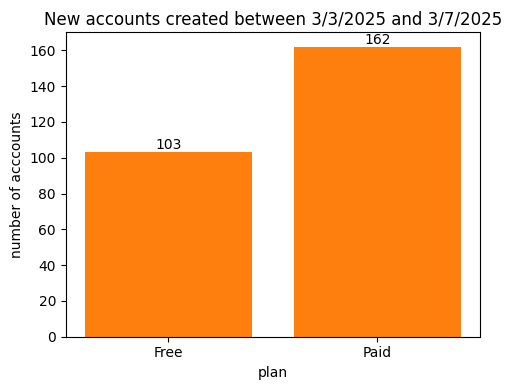

In [58]:
plt.figure(figsize = (5,4))
plt.bar(df_cohort['plan'], df_cohort['userid'])
plt.title("New accounts created between 3/3/2025 and 3/7/2025")
plt.xlabel("plan")
plt.ylabel("number of acccounts")

bars = plt.bar(
    df_cohort["plan"].astype(str),
    df_cohort["userid"]
)


# Add numbers on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,   # x position (center of bar)
        height,                            # y position
        f"{int(height)}",                  # text
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [62]:
new_users = df[df['startdate'].between(COHORT_START, COHORT_END)]['userid'].unique()
cohort= df[df['userid'].isin(new_users)]

# limite 60 days 
cohort60 = cohort[cohort['DaysSinceStart'] <= 60]

In [66]:
'''
Conversion definition

A user:

starts as Free (based on user_first)

has any row with plan == Paid in day 0..59
'''

free_starters = cohort60[cohort60['plan'] == 'Free']['userid'].unique()

ever_paid_in_60 = cohort60[cohort60['userid'].isin(free_starters) & (cohort60['plan'] == 'Paid')]['userid'].unique()

conversion_rate = len(ever_paid_in_60) / len(free_starters) if len(free_starters) > 0 else 0

print(f"Conversion count {len(ever_paid_in_60)}, Conversion rate from Free to Paid within 60 days: {conversion_rate:.2%}")



Conversion count 65, Conversion rate from Free to Paid within 60 days: 63.11%


In [70]:
'''
Relationship to activities: do converters behave differently?
'''

# flag converters among free starters 
free_user_labels = pd.DataFrame({
    'userid': free_starters,
    'converted': [1 if u in ever_paid_in_60 else 0 for u in free_starters]
})

# aggregate first week usage 
w0 = cohort60[cohort60['DaysSinceStart'] < 7].copy()

per_user_w0 = w0.groupby('userid').agg(
          w0_interactions=("total_interactions", "sum"),
          w0_active_days=("is_active_day", "sum"),
          w0_autocomplete_success=("AI_AutoComplete_Success", "sum"),
          w0_chat_success=("AI_Chat_Success", "sum"),
          w0_agent_success=("AI_Agent_Success", "sum"),
          w0_errors=("AI_AutoComplete_Error", "sum"),
).reset_index()

analysis = free_user_labels.merge(per_user_w0, on="userid", how="left").fillna(0)
analysis.groupby("converted")[["w0_interactions","w0_active_days","w0_chat_success","w0_agent_success","w0_errors"]].mean().reset_index()


,converted,w0_interactions,w0_active_days,w0_chat_success,w0_agent_success,w0_errors
0,0,266.236842,7.0,34.618421,12.276316,13.039474
1,1,258.323077,7.0,32.053846,12.661538,12.246154


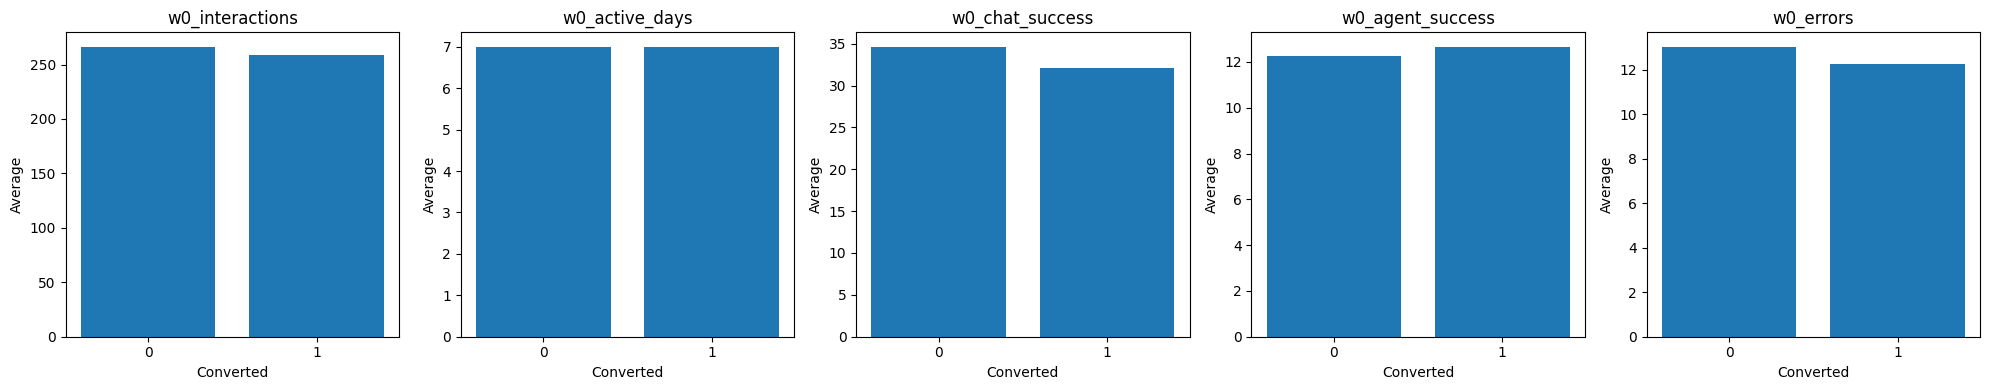

In [72]:
# create side by side bar charts for interactions, active days, chat success, agent success, and errors
metrics = ["w0_interactions", "w0_active_days", "w0_chat_success", "w0_agent_success", "w0_errors"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))
for i, metric in enumerate(metrics):
    means = analysis.groupby("converted")[metric].mean()
    axes[i].bar(means.index.astype(str), means.values)
    axes[i].set_title(metric)
    axes[i].set_xlabel("Converted")
    axes[i].set_ylabel("Average")

plt.tight_layout()
plt.show()

In [78]:
'''
Q2) How many accounts are still using the product? What is retention rate?
'''


'''
(A) Weekly retention (recommended): any activity within each week window

This is more stable than “exact day” retention.
'''
cohort_size = len(new_users)

# deduplicate user-day 
user_day_activity = (
    cohort60[['userid', 'DaysSinceStart', 'is_active_day']].drop_duplicates(subset=['userid', 'DaysSinceStart'])
)

week_windows = [
    (0,6,"W0 (0-6)"),
    (7,13,"W1 (7-13)"),
    (14,20,"W2 (14-20)"),
    (21,27,"W3 (21-27)"),
    (28,34,"W4 (28-34)"),
    (35,41,"W5 (35-41)"),
    (42,48,"W6 (42-48)"),
    (49,55,"W7 (49-55)"),
    (56,62,"W8 (56-62)")
]

weekly_ret = []
for lo, hi, label in week_windows:
    active_users = user_day_activity[
        (user_day_activity['DaysSinceStart'] >= lo) & 
        (user_day_activity['DaysSinceStart'] <= hi) &
        (user_day_activity['is_active_day'])
    ]['userid'].nunique()
    retention_rate = active_users / cohort_size if cohort_size > 0 else 0
    weekly_ret.append((label, active_users, retention_rate))

weekly_ret_df = pd.DataFrame(weekly_ret, columns=['Week', 'ActiveUsers', 'RetentionRate'])
print(weekly_ret_df)

         Week  ActiveUsers  RetentionRate
0    W0 (0-6)          200            1.0
1   W1 (7-13)          200            1.0
2  W2 (14-20)          200            1.0
3  W3 (21-27)          200            1.0
4  W4 (28-34)          200            1.0
5  W5 (35-41)          200            1.0
6  W6 (42-48)          200            1.0
7  W7 (49-55)          200            1.0
8  W8 (56-62)          200            1.0


In [79]:
# can you create cohort retention table by week, with new users as rows and weeks as columns, showing retention rates?
# Create a retention table with users as rows and weeks as columns
retention_table = pd.DataFrame({'userid': new_users})
for lo, hi, label in week_windows:
    retention_table[label] = retention_table['userid'].apply(
        lambda u: int(
            ((cohort60['userid'] == u) & 
             (cohort60['DaysSinceStart'] >= lo) & 
             (cohort60['DaysSinceStart'] <= hi) & 
             (cohort60['is_active_day'])
            ).any()
        )
    )
retention_table.set_index('userid', inplace=True)
print(retention_table.head())

          W0 (0-6)  W1 (7-13)  W2 (14-20)  W3 (21-27)  W4 (28-34)  W5 (35-41)  \
userid                                                                          
10000000         1          1           1           1           1           1   
10000001         1          1           1           1           1           1   
10000002         1          1           1           1           1           1   
10000003         1          1           1           1           1           1   
10000004         1          1           1           1           1           1   

          W6 (42-48)  W7 (49-55)  W8 (56-62)  
userid                                        
10000000           1           1           1  
10000001           1           1           1  
10000002           1           1           1  
10000003           1           1           1  
10000004           1           1           1  


In [86]:
'''
Q3) How many Free accounts upgraded to Paid? What is conversion rate?

Definition I recommend using in interview:

Consider only Free starters

A conversion happens if the user ever has plan=Paid after having been Free within 60 days
'''

def converted_free_to_paid(g):
    g = g.sort_values("DaysSinceStart")
    plans = g["plan"].ffill()
    seen_free = False
    for p in plans:
        if p == "Free":
            seen_free = True
        if p == "Paid" and seen_free:
            return True
    return False

cohort60_sorted = cohort60.sort_values(["userid", "DaysSinceStart"])

# Forward fill within each user
cohort60_sorted["plan_ffill"] = (
    cohort60_sorted
    .groupby("userid")["plan"]
    .ffill()
)


# Check if ever Paid within 60 days
converted = (
    cohort60_sorted
    .groupby("userid")["plan_ffill"]
    .apply(lambda s: (s == "Paid").any())
)

converted_free_to_paid = converted.loc[new_users]

# Calculate conversion rate
conversion_rate = converted_free_to_paid.mean()
print(f"Conversion count: {converted_free_to_paid.sum()}, Conversion rate from Free to Paid within 60 days: {conversion_rate:.2%}")


Conversion count: 162, Conversion rate from Free to Paid within 60 days: 81.00%


In [88]:
def first_conversion_day(g):
    g = g.sort_values("DaysSinceStart")
    plans = g["plan"].ffill()
    seen_free = False
    for day, p in zip(g["DaysSinceStart"], plans):
        if p == "Free":
            seen_free = True
        if p == "Paid" and seen_free:
            return int(day)
    return np.nan

conv_day = cohort60.groupby("userid").apply(first_conversion_day)
conv_day.name = "first_conversion_day"

conv_days = conv_day.loc[free_starters].dropna()
conv_days.describe()

/var/folders/5f/k8zf5ltx2wz80yv295m10dsc0000gn/T/ipykernel_76378/2234502435.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conv_day = cohort60.groupby("userid").apply(first_conversion_day)


count    65.000000
mean     25.876923
std      14.212129
min       6.000000
25%      14.000000
50%      23.000000
75%      34.000000
max      57.000000
Name: first_conversion_day, dtype: float64

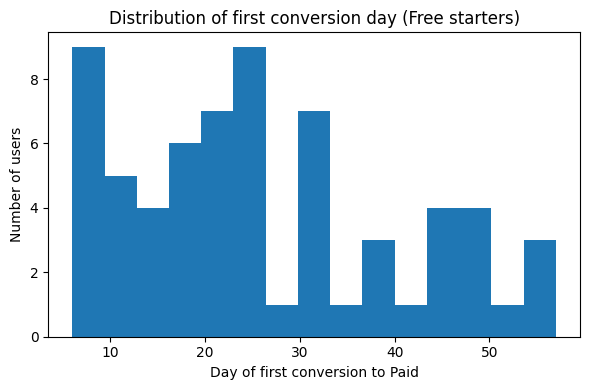

In [89]:
plt.figure(figsize=(6,4))
plt.hist(conv_days, bins=15)
plt.title("Distribution of first conversion day (Free starters)")
plt.xlabel("Day of first conversion to Paid")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

In [92]:
'''
Q4) How many Paid accounts have cancelled?

You should clarify the definition (in your narration) because product teams often mean:

(A) Cancellation among Paid starters

and/or

(B) Cancellation among users who ever became Paid

We can do both.
'''

def cancelled_while_paid(g):
    g = g.sort_values("DaysSinceStart")
    plan = g["plan"].ffill()
    status = g["Status"]
    return ((status == "Cancelled") & (plan == "Paid")).any()

def infer_start_plan(g):
    g = g.sort_values("DaysSinceStart")
    # Prefer day 0-2 plans
    p = g.loc[g["DaysSinceStart"].between(0, 2), "plan"].dropna()
    if len(p) > 0:
        return p.iloc[0]
    # Fallback: first non-null plan in 60-day window
    p2 = g["plan"].dropna()
    return p2.iloc[0] if len(p2) > 0 else np.nan

cancelled_paid = cohort60.groupby("userid").apply(cancelled_while_paid)
cancelled_paid.name = "cancelled_while_paid"

start_plan = cohort60.groupby("userid").apply(infer_start_plan)
start_plan.name = "start_plan"

# Ever paid
ever_paid = cohort60.groupby("userid")["plan"].apply(lambda s: (s.ffill() == "Paid").any())

paid_starters = start_plan[start_plan == "Paid"].index

# Metrics
paid_starter_cancel_count = int(cancelled_paid.loc[paid_starters].sum()) if len(paid_starters) else 0
paid_starter_cancel_rate = float(cancelled_paid.loc[paid_starters].mean()) if len(paid_starters) else np.nan

ever_paid_cancel_count = int(cancelled_paid.loc[ever_paid[ever_paid].index].sum()) if ever_paid.any() else 0
ever_paid_cancel_rate = float(cancelled_paid.loc[ever_paid[ever_paid].index].mean()) if ever_paid.any() else np.nan

paid_starter_cancel_count, paid_starter_cancel_rate, ever_paid_cancel_count, ever_paid_cancel_rate


/var/folders/5f/k8zf5ltx2wz80yv295m10dsc0000gn/T/ipykernel_76378/997217101.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cancelled_paid = cohort60.groupby("userid").apply(cancelled_while_paid)
/var/folders/5f/k8zf5ltx2wz80yv295m10dsc0000gn/T/ipykernel_76378/997217101.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  start_plan = cohort60.groupby("userid").apply(infer_start_plan)


(84, 0.865979381443299, 143, 0.8827160493827161)

In [93]:
df['plan'].unique()

array(['Free', 'Paid'], dtype=object)

In [95]:
df['Status'].unique()

array(['Active', 'Cancelled'], dtype=object)